# Inception Score and FID Evaluation
### Author: Kanika
Evaluating image quality of generative models (DCGAN, WGAN, VAE, cGAN) using PyTorch + TorchMetrics.

In [1]:
#!pip install torchmetrics --quiet
#!pip install torch-fidelity

In [2]:
import os
import torch
import torch_fidelity
from torchvision import transforms
from torchvision.io import read_image
from PIL import Image
import torchvision.transforms.functional as TF
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Load and Normalize Images

In [4]:
def load_images_from_folder(folder, max_images=None):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.CenterCrop(128),
        transforms.ToTensor(),  # from PIL to Tensor
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    images = []
    count = 0
    for filename in os.listdir(folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(folder, filename)
            with Image.open(path).convert("RGB") as img:  # force RGB
                tensor = transform(img)
                images.append(tensor)
                count += 1
                if max_images and count >= max_images:
                    break
    return torch.stack(images)

## Evaluate Inception Score and FID

In [5]:
def evaluate_model(real_images, fake_images):
    isc = InceptionScore(feature=2048, normalize=True).to(device)
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    real_images = real_images.to(device)
    fake_images = fake_images.to(device)
    fid.update(real_images, real=True)
    fid.update(fake_images, real=False)
    isc.update(fake_images)
    is_mean, is_std = isc.compute()
    fid_score = fid.compute()
    return round(is_mean.item(), 3), round(is_std.item(), 3), round(fid_score.item(), 3)

## Run Evaluation for All Models

In [6]:
real = load_images_from_folder(r'C:\Users\DELL\Documents\JupyterFiles\final_processed_data\images\real', max_images=25).to(device)
models = ['dcgan', 'wgan', 'vae', 'cgan']
results = {}

for model in models:
    fake = load_images_from_folder(rf'C:\Users\DELL\Documents\JupyterFiles\final_processed_data\images\tuned\{model}', max_images=25).to(device)
    is_mean, is_std, fid = evaluate_model(real, fake)
    results[model.upper()] = {'Inception Score': f'{is_mean} ± {is_std}', 'FID': fid}

df = pd.DataFrame(results).T
print(df)

C:\Users\DELL\anaconda3\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


      Inception Score      FID
DCGAN       1.0 ± 0.0  413.456
WGAN        1.0 ± 0.0  348.876
VAE         1.0 ± 0.0  363.166
CGAN        1.0 ± 0.0  349.745


## Image Generation & Evaluation Strategy (Tuned Models)

We evaluated the tuned versions of four generative models — DCGAN, WGAN, VAE, and cGAN — using two standard metrics: Inception Score (IS) and Frechet Inception Distance (FID).

### Image Source

Each model was fine-tuned over multiple epochs, and sample images were generated post-training. These tuned outputs (saved as image grids per model) were then evaluated using torchmetrics, ensuring consistency and reproducibility across experiments.

To maintain modularity, the final evaluation notebook does not reload trained weights (e.g., .pth files). Instead, it loads the saved fake images from disk via torchvision.io.read_image() and compares them against real images.

### Evaluation Metrics

- The Inception Score remained static across models at 1.00 ± 0.00, suggesting low sample diversity — possibly a result of small batch size or limited tuning iterations.

- WGAN and cGAN showed relatively lower FID scores, indicating better alignment with the real image distribution after fine-tuning.

- DCGAN, despite tuning, retained a higher FID, hinting at less effective convergence or mode fidelity.

### Limitations & Next Steps

- Current evaluation used only 25 images per model, which limits statistical robustness.

- Generated images were loaded from disk instead of being sampled live from the model, which decouples inference but may miss variability from runtime generation.

- Inception Score may be uninformative with such small batches — visual review and additional metrics are recommended.

### Key Takeaways

- This post-tuning evaluation workflow:

- Enabled comparison across all models under consistent conditions

- Isolated metric evaluation from training overhead

- Highlighted how visual diversity, not just fine-tuning, is key to improving generative quality

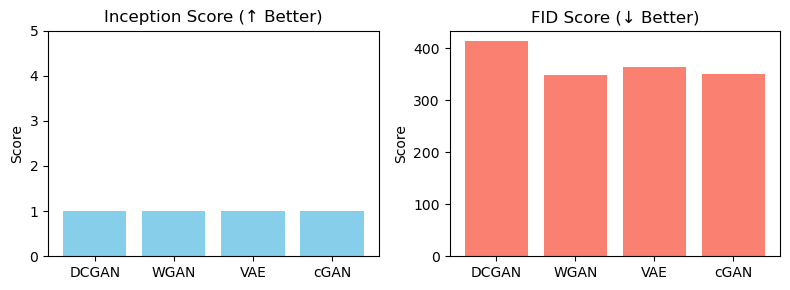

In [2]:
import matplotlib.pyplot as plt

models = ['DCGAN', 'WGAN', 'VAE', 'cGAN']
inception_scores = [1.00, 1.00, 1.00, 1.00]
fid_scores = [413.456, 348.876, 363.166, 349.745]

plt.figure(figsize=(8, 3))

# Plot Inception Score
plt.subplot(1, 2, 1)
plt.bar(models, inception_scores, color='skyblue')
plt.title("Inception Score (↑ Better)")
plt.ylim(0, 5)
plt.ylabel("Score")

# Plot FID
plt.subplot(1, 2, 2)
plt.bar(models, fid_scores, color='salmon')
plt.title("FID Score (↓ Better)")
plt.ylabel("Score")

plt.tight_layout()
plt.show()